In [1]:
import pandas as pd

In [9]:
sales = pd.read_csv("Sales_October_2019.csv")
sales.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,259358,34in Ultrawide Monitor,1,379.99,10/28/19 10:56,"609 Cherry St, Dallas, TX 75001"
1,259359,27in 4K Gaming Monitor,1,389.99,10/28/19 17:26,"225 5th St, Los Angeles, CA 90001"
2,259360,AAA Batteries (4-pack),2,2.99,10/24/19 17:20,"967 12th St, New York City, NY 10001"
3,259361,27in FHD Monitor,1,149.99,10/14/19 22:26,"628 Jefferson St, New York City, NY 10001"
4,259362,Wired Headphones,1,11.99,10/07/19 16:10,"534 14th St, Los Angeles, CA 90001"


In [10]:
sales.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
20374,278792,AA Batteries (4-pack),1,3.84,10/12/19 04:32,"920 Adams St, San Francisco, CA 94016"
20375,278793,Wired Headphones,1,11.99,10/28/19 22:00,"161 Chestnut St, Los Angeles, CA 90001"
20376,278794,AA Batteries (4-pack),1,3.84,10/09/19 20:58,"346 Spruce St, San Francisco, CA 94016"
20377,278795,iPhone,1,700,10/31/19 17:21,"291 Hill St, Seattle, WA 98101"
20378,278796,Wired Headphones,1,11.99,10/13/19 11:20,"547 Jefferson St, Los Angeles, CA 90001"


In [65]:
# Renommer la colonne des quantité
sales.rename(columns={'Quantity Ordered' : 'Quantité'}, inplace=True)
sales.head()

,Order ID,Product,Quantité,Price Each,Order Date,Purchase Address
0,259358,34in Ultrawide Monitor,1.0,379.99,10/28/19 10:56,"609 Cherry St, Dallas, TX 75001"
1,259359,27in 4K Gaming Monitor,1.0,389.99,10/28/19 17:26,"225 5th St, Los Angeles, CA 90001"
2,259360,AAA Batteries (4-pack),2.0,2.99,10/24/19 17:20,"967 12th St, New York City, NY 10001"
3,259361,27in FHD Monitor,1.0,149.99,10/14/19 22:26,"628 Jefferson St, New York City, NY 10001"
4,259362,Wired Headphones,1.0,11.99,10/07/19 16:10,"534 14th St, Los Angeles, CA 90001"


In [79]:
# Renommer le prix, la date, le produit et l'adresse 
sales.rename(columns={
    'Product': 'Produit',
    'Price Each': 'Prix',
    'Order Date': 'Date',
    'Purchase Address': 'Adresse',

}, inplace=True)

sales.head()

,Produit,Quantité,Prix,Date,Adresse
0,34in Ultrawide Monitor,1.0,379.99,10/28/19 10:56,"609 Cherry St, Dallas, TX 75001"
1,27in 4K Gaming Monitor,1.0,389.99,10/28/19 17:26,"225 5th St, Los Angeles, CA 90001"
2,AAA Batteries (4-pack),2.0,2.99,10/24/19 17:20,"967 12th St, New York City, NY 10001"
3,27in FHD Monitor,1.0,149.99,10/14/19 22:26,"628 Jefferson St, New York City, NY 10001"
4,Wired Headphones,1.0,11.99,10/07/19 16:10,"534 14th St, Los Angeles, CA 90001"


In [84]:
# Spprimer la colonne Date
# sales.drop(columns=["Date"], inplace=True)
sales.head()

,Produit,Quantité,Prix,Adresse
0,34in Ultrawide Monitor,1.0,379.99,"609 Cherry St, Dallas, TX 75001"
1,27in 4K Gaming Monitor,1.0,389.99,"225 5th St, Los Angeles, CA 90001"
2,AAA Batteries (4-pack),2.0,2.99,"967 12th St, New York City, NY 10001"
3,27in FHD Monitor,1.0,149.99,"628 Jefferson St, New York City, NY 10001"
4,Wired Headphones,1.0,11.99,"534 14th St, Los Angeles, CA 90001"


In [85]:
sales.info

<bound method DataFrame.info of                       Produit  Quantité    Prix  \
0      34in Ultrawide Monitor       1.0  379.99   
1      27in 4K Gaming Monitor       1.0  389.99   
2      AAA Batteries (4-pack)       2.0    2.99   
3            27in FHD Monitor       1.0  149.99   
4            Wired Headphones       1.0   11.99   
...                       ...       ...     ...   
20374   AA Batteries (4-pack)       1.0    3.84   
20375        Wired Headphones       1.0   11.99   
20376   AA Batteries (4-pack)       1.0    3.84   
20377                  iPhone       1.0  700.00   
20378        Wired Headphones       1.0   11.99   

                                         Adresse  
0                609 Cherry St, Dallas, TX 75001  
1              225 5th St, Los Angeles, CA 90001  
2           967 12th St, New York City, NY 10001  
3      628 Jefferson St, New York City, NY 10001  
4             534 14th St, Los Angeles, CA 90001  
...                                          ... 

In [86]:
sales.shape

(20379, 4)

In [87]:
sales.dtypes

Produit      object
Quantité    float64
Prix        float64
Adresse      object
dtype: object

In [88]:
# Voir les valeurs manquantes dans la base de données
sales.isnull().sum()

Produit     62
Quantité    95
Prix        95
Adresse     62
dtype: int64

In [89]:
sales.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Produit', 'Quantité', 'Prix', 'Adresse'], dtype='object')>

In [90]:
# Quantification des valeurs manquantes
sales.isnull().mean() * 100

Produit     0.304235
Quantité    0.466166
Prix        0.466166
Adresse     0.304235
dtype: float64

In [92]:
# Produits les plus vendu
# sales["Quantité"] = pd.to_numeric(sales["Quantité"], errors="coerce")

quantite_vendue = (
    sales.groupby("Produit")["Quantité"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
quantite_vendue.columns = ["Produit", "Quantité vendue"]

quantite_vendue.head(10)

,Produit,Quantité vendue
0,AAA Batteries (4-pack),3362.0
1,AA Batteries (4-pack),2939.0
2,USB-C Charging Cable,2669.0
3,Lightning Charging Cable,2570.0
4,Wired Headphones,2274.0
5,Apple Airpods Headphones,1674.0
6,Bose SoundSport Headphones,1465.0
7,27in FHD Monitor,792.0
8,27in 4K Gaming Monitor,723.0
9,iPhone,716.0


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16092\2580756773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quantite_vendue, x="Quantité vendue", y = "Produit",


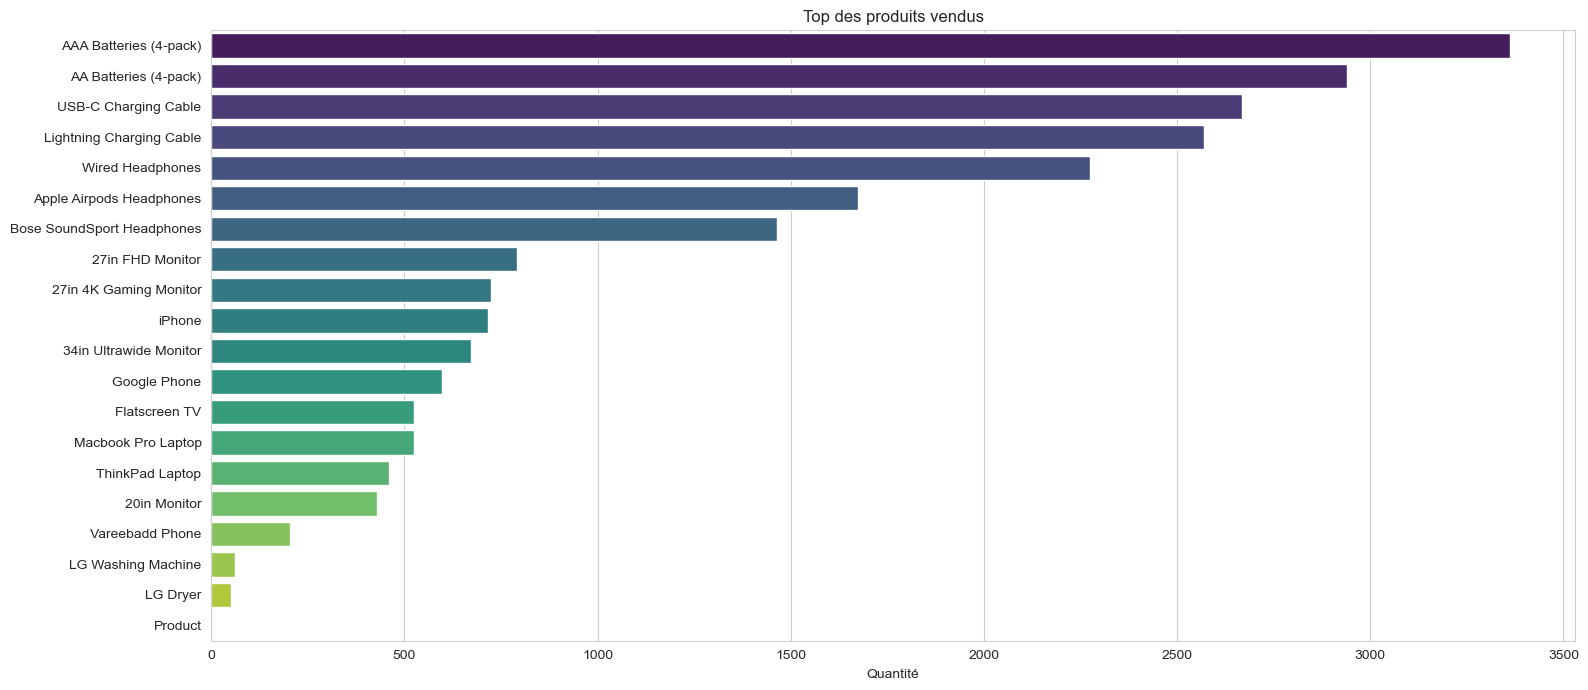

In [93]:
fig, axes = plt.subplots(figsize=(16,7))
sns.barplot(data=quantite_vendue, x="Quantité vendue", y = "Produit",
           palette="viridis", ax=axes)
axes.set_title("Top des produits vendus")
axes.set_xlabel("Quantité")
axes.set_ylabel("")

plt.tight_layout()

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16092\703852649.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


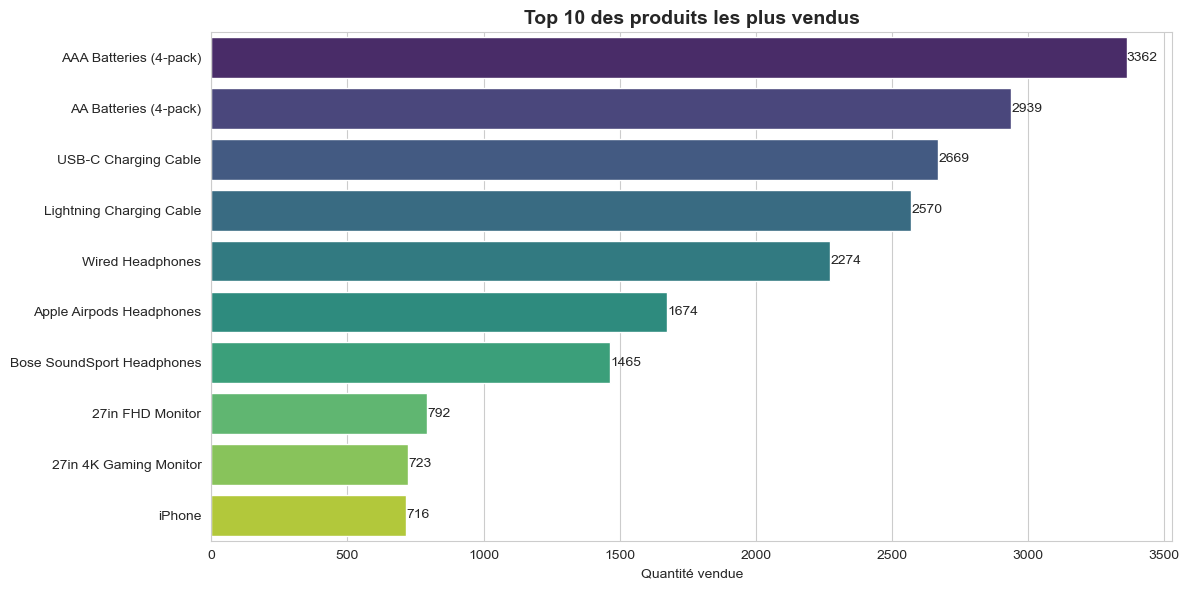

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prendre seulement le top 10
top10 = quantite_vendue.head(10)

# Style plus propre
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Quantité vendue",
    y="Produit",
    palette="viridis",
    ax=ax
)

ax.set_title("Top 10 des produits les plus vendus", fontsize=14, weight="bold")
ax.set_xlabel("Quantité vendue")
ax.set_ylabel("")

# Ajouter les valeurs sur les barres
for i, v in enumerate(top10["Quantité vendue"]):
    ax.text(v + 0.5, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

In [94]:
# Chiffre d'affaire

# sales["Prix"] = pd.to_numeric(sales["Prix"], errors="coerce")

produits_ca = (
    sales.groupby("Produit")["Prix"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
produits_ca.columns = ["Produit", "CA"]

produits_ca.head(10)

,Produit,CA
0,Macbook Pro Laptop,892500.00
1,iPhone,500500.00
2,ThinkPad Laptop,458995.41
3,Google Phone,358200.00
4,27in 4K Gaming Monitor,280402.81
5,34in Ultrawide Monitor,254973.29
6,Apple Airpods Headphones,249750.00
7,Flatscreen TV,157200.00
8,Bose SoundSport Headphones,143985.60
9,27in FHD Monitor,118642.09
